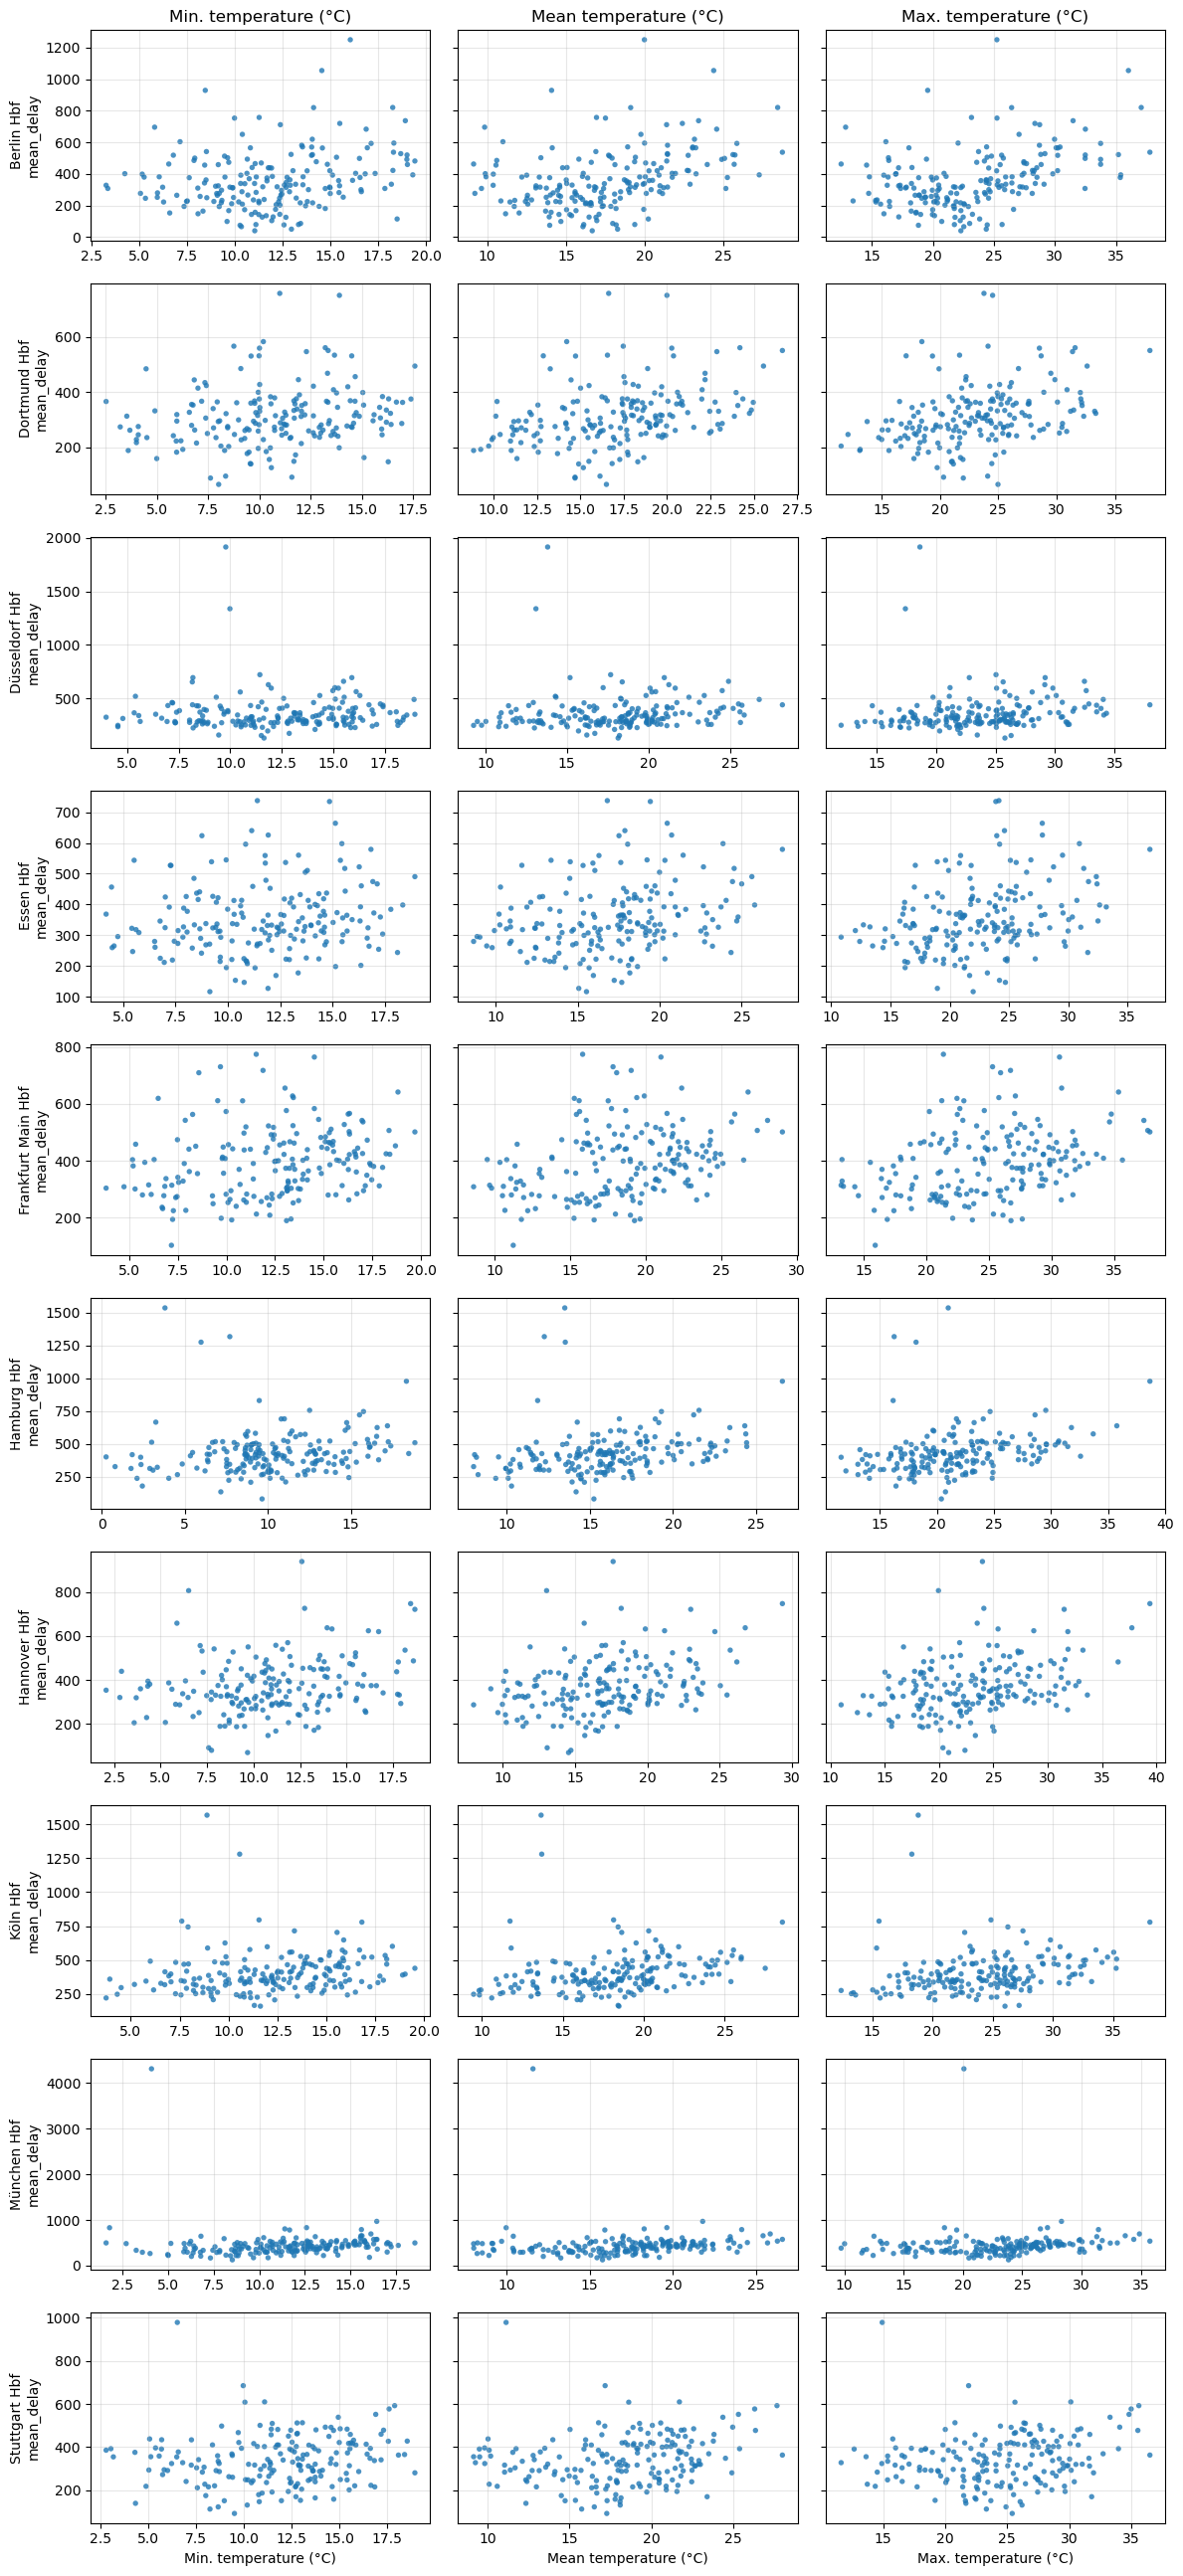

In [14]:
import glob
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# ---- settings ----
csv_dir = Path("/home/b/b383514/other/Train_Disrubtion/data/processed_new")
#out_file = csv_dir / "delay_vs_temperature.png"
DELAY_COL = "mean_delay"          # or "fraction_delayed"
TEMP_COLS = ["tn", "tg", "tx"]
TEMP_LABELS = {"tn": "Min. temperature (°C)",
               "tg": "Mean temperature (°C)",
               "tx": "Max. temperature (°C)"}
# ------------------

files = sorted(csv_dir.glob("*.csv"))
n = len(files)

fig, axes = plt.subplots(n, 3, figsize=(12, 2.6 * n), sharey="row", squeeze=False)

for i, f in enumerate(files):
    d = pd.read_csv(f, parse_dates=["date"])
    city = f.stem.replace("_", " ")
    for j, var in enumerate(TEMP_COLS):
        ax = axes[i, j]
        ax.scatter(d[var], d[DELAY_COL], s=15, alpha=0.8, edgecolor="none")
        ax.grid(alpha=0.3)
        if j == 0:
            ax.set_ylabel(f"{city}\n{DELAY_COL}")
        if i == 0:
            ax.set_title(TEMP_LABELS[var])
        if i == n - 1:
            ax.set_xlabel(TEMP_LABELS[var])

fig.tight_layout()
#fig.savefig(out_file, dpi=150)
plt.show()
#print("saved:", out_file)

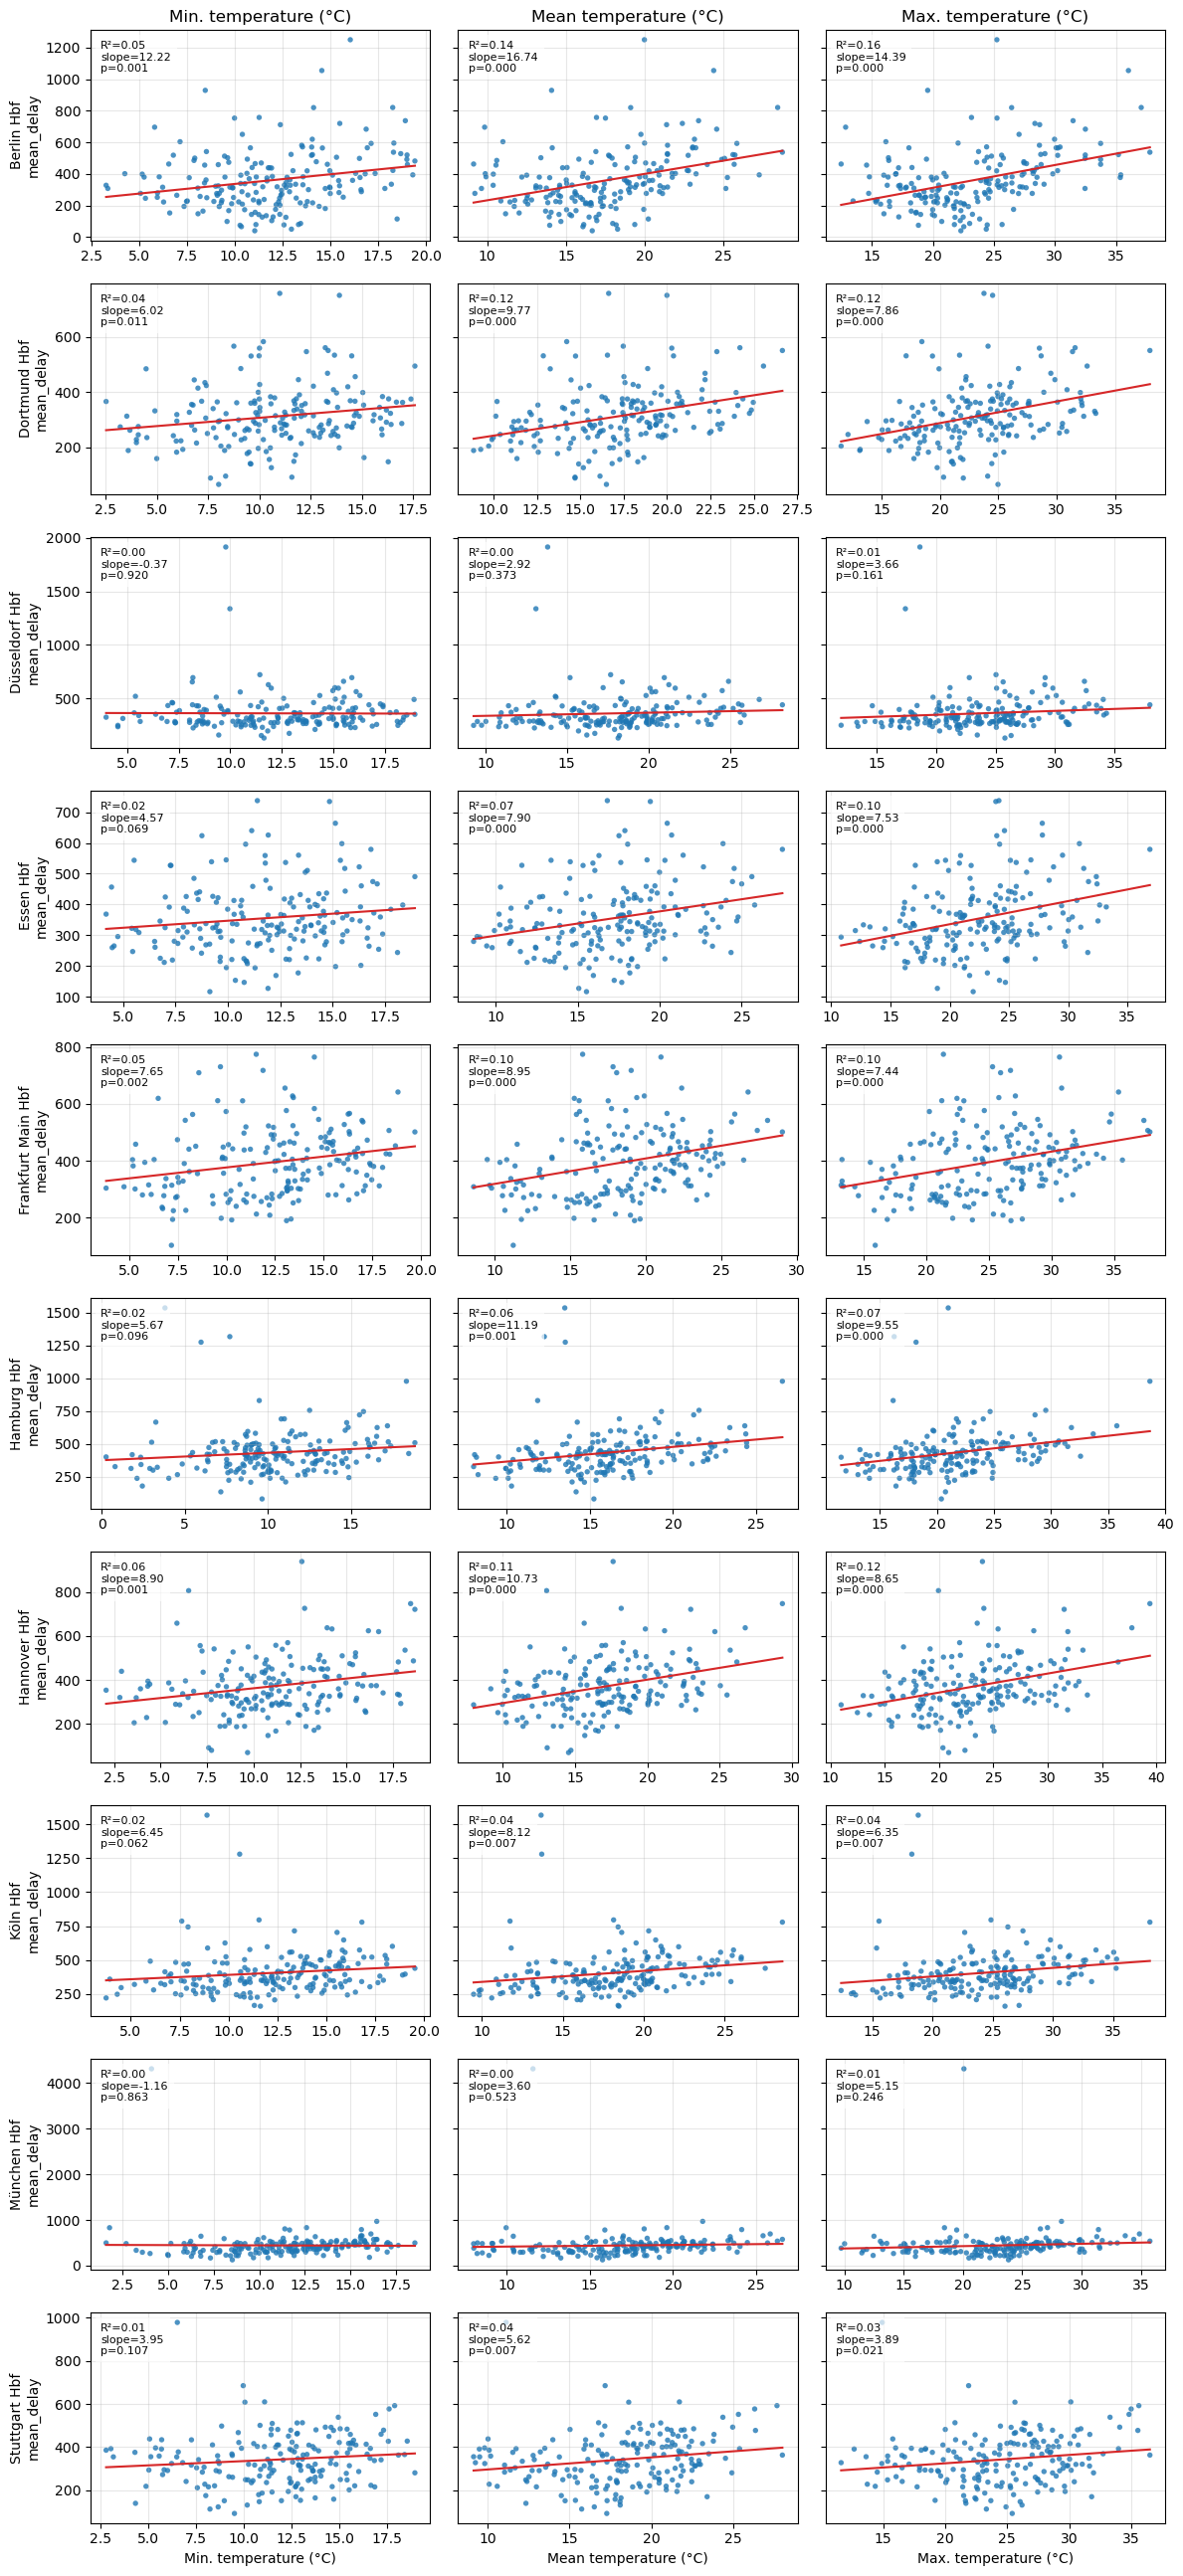

              city variable   n  slope  intercept      r    R2  p_value  stderr_slope
        Berlin Hbf       tn 185 12.218    214.452  0.233 0.054    0.001         3.771
        Berlin Hbf       tg 185 16.741     65.641  0.371 0.138    0.000         3.095
        Berlin Hbf       tx 185 14.390     24.506  0.403 0.163    0.000         2.414
      Dortmund Hbf       tn 185  6.020    246.812  0.187 0.035    0.011         2.332
      Dortmund Hbf       tg 185  9.771    144.500  0.340 0.115    0.000         2.001
      Dortmund Hbf       tx 185  7.858    130.536  0.347 0.121    0.000         1.569
    Düsseldorf Hbf       tn 185 -0.374    365.151 -0.007 0.000    0.920         3.703
    Düsseldorf Hbf       tg 185  2.916    308.087  0.066 0.004    0.373         3.268
    Düsseldorf Hbf       tx 185  3.663    273.646  0.103 0.011    0.161         2.604
         Essen Hbf       tn 185  4.571    301.642  0.134 0.018    0.069         2.498
         Essen Hbf       tg 185  7.903    219.602  0.2

In [15]:
import glob
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# ---- settings ----
csv_dir = Path("/home/b/b383514/other/Train_Disrubtion/data/processed_new")
#out_file = csv_dir / "delay_vs_temperature.png"
DELAY_COL = "mean_delay"          # or "fraction_delayed"
TEMP_COLS = ["tn", "tg", "tx"]
TEMP_LABELS = {"tn": "Min. temperature (°C)",
               "tg": "Mean temperature (°C)",
               "tx": "Max. temperature (°C)"}
# ------------------

files = sorted(csv_dir.glob("*.csv"))
n = len(files)
results = []

fig, axes = plt.subplots(n, 3, figsize=(12, 2.6 * n), sharey="row", squeeze=False)

for i, f in enumerate(files):
    d = pd.read_csv(f, parse_dates=["date"])
    city = f.stem.replace("_", " ")
    for j, var in enumerate(TEMP_COLS):
        ax = axes[i, j]
        ax.scatter(d[var], d[DELAY_COL], s=15, alpha=0.8, edgecolor="none")

        # --- linear regression (rows with both values present) ---
        sub = d[[var, DELAY_COL]].dropna()
        if len(sub) > 2:
            res = stats.linregress(sub[var], sub[DELAY_COL])
            xs = np.array([sub[var].min(), sub[var].max()])
            ax.plot(xs, res.intercept + res.slope * xs, color="C3", lw=1.5)
            ax.text(0.03, 0.95,
                    f"R²={res.rvalue**2:.2f}\nslope={res.slope:.2f}\np={res.pvalue:.3f}",
                    transform=ax.transAxes, va="top", fontsize=8,
                    bbox=dict(fc="white", ec="none", alpha=0.7))
            results.append({"city": city, "variable": var, "n": len(sub),
                            "slope": res.slope, "intercept": res.intercept,
                            "r": res.rvalue, "R2": res.rvalue**2,
                            "p_value": res.pvalue, "stderr_slope": res.stderr})

        ax.grid(alpha=0.3)
        if j == 0:
            ax.set_ylabel(f"{city}\n{DELAY_COL}")
        if i == 0:
            ax.set_title(TEMP_LABELS[var])
        if i == n - 1:
            ax.set_xlabel(TEMP_LABELS[var])

fig.tight_layout()
#fig.savefig(out_file, dpi=150)
plt.show()

summary = pd.DataFrame(results)
print(summary.round(3).to_string(index=False))
#summary.to_csv(csv_dir / "regression_summary.csv", index=False)

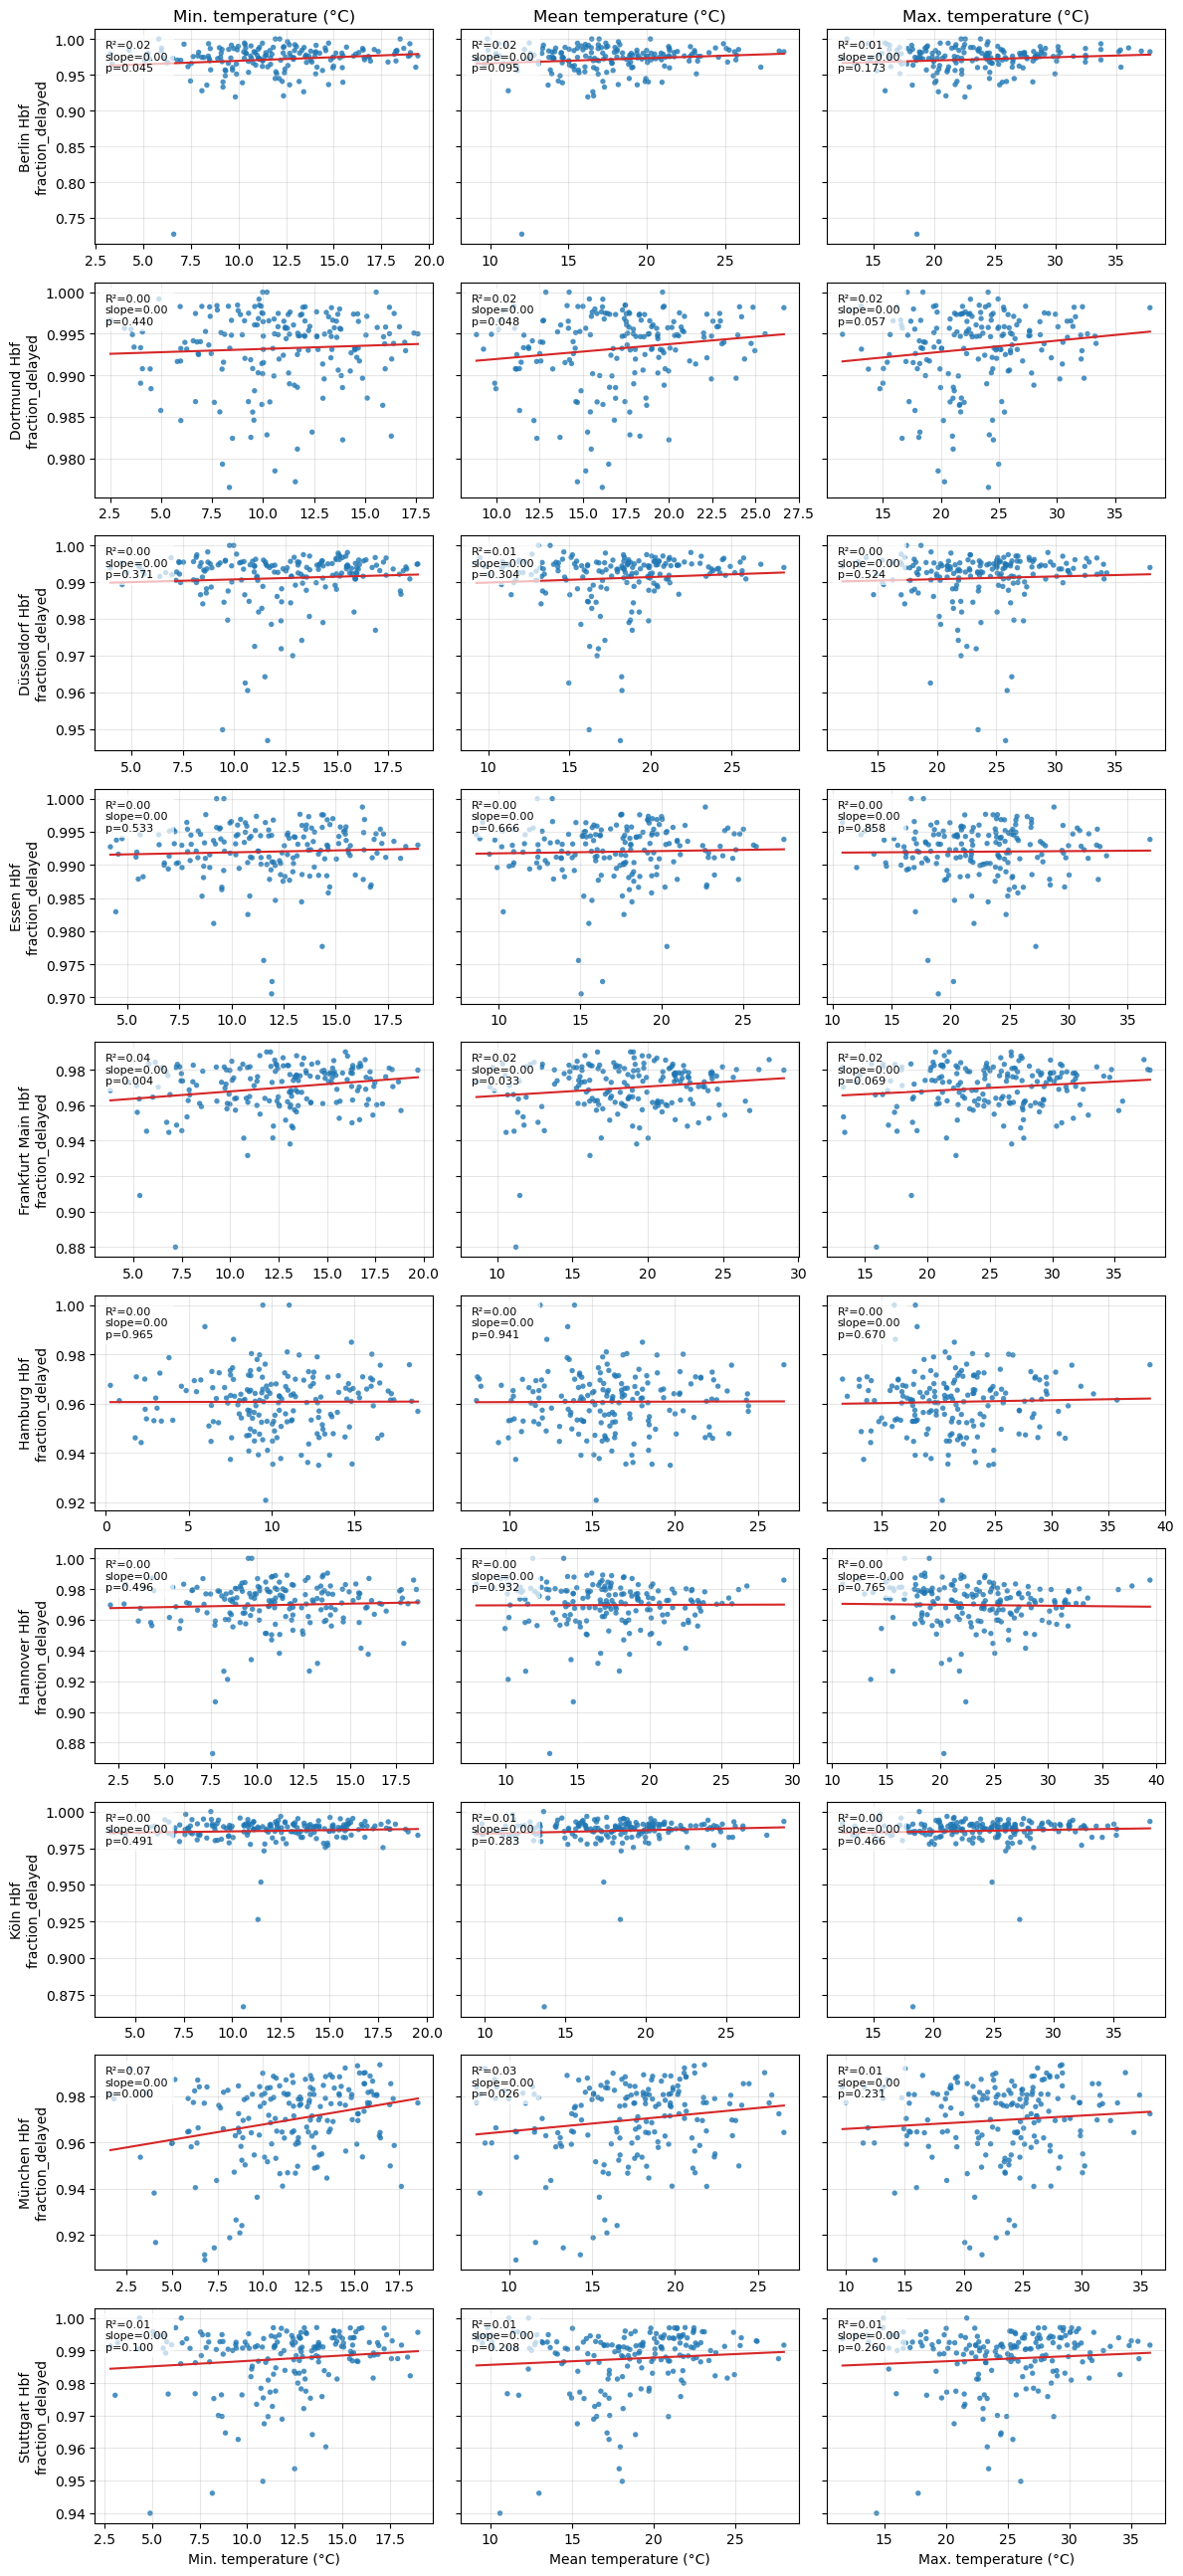

              city variable   n  slope  intercept      r    R2  p_value  stderr_slope
        Berlin Hbf       tn 185  0.001      0.959  0.148 0.022    0.045           0.0
        Berlin Hbf       tg 185  0.001      0.959  0.123 0.015    0.095           0.0
        Berlin Hbf       tx 185  0.000      0.961  0.101 0.010    0.173           0.0
      Dortmund Hbf       tn 185  0.000      0.992  0.057 0.003    0.440           0.0
      Dortmund Hbf       tg 185  0.000      0.990  0.146 0.021    0.048           0.0
      Dortmund Hbf       tx 185  0.000      0.990  0.140 0.020    0.057           0.0
    Düsseldorf Hbf       tn 185  0.000      0.989  0.066 0.004    0.371           0.0
    Düsseldorf Hbf       tg 185  0.000      0.988  0.076 0.006    0.304           0.0
    Düsseldorf Hbf       tx 185  0.000      0.989  0.047 0.002    0.524           0.0
         Essen Hbf       tn 185  0.000      0.991  0.046 0.002    0.533           0.0
         Essen Hbf       tg 185  0.000      0.991  0.0

In [16]:
import glob
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# ---- settings ----
csv_dir = Path("/home/b/b383514/other/Train_Disrubtion/data/processed_new")
#out_file = csv_dir / "delay_vs_temperature.png"
DELAY_COL = "fraction_delayed"          # or "fraction_delayed"
TEMP_COLS = ["tn", "tg", "tx"]
TEMP_LABELS = {"tn": "Min. temperature (°C)",
               "tg": "Mean temperature (°C)",
               "tx": "Max. temperature (°C)"}
# ------------------

files = sorted(csv_dir.glob("*.csv"))
n = len(files)
results = []

fig, axes = plt.subplots(n, 3, figsize=(12, 2.6 * n), sharey="row", squeeze=False)

for i, f in enumerate(files):
    d = pd.read_csv(f, parse_dates=["date"])
    city = f.stem.replace("_", " ")
    for j, var in enumerate(TEMP_COLS):
        ax = axes[i, j]
        ax.scatter(d[var], d[DELAY_COL], s=15, alpha=0.8, edgecolor="none")

        # --- linear regression (rows with both values present) ---
        sub = d[[var, DELAY_COL]].dropna()
        if len(sub) > 2:
            res = stats.linregress(sub[var], sub[DELAY_COL])
            xs = np.array([sub[var].min(), sub[var].max()])
            ax.plot(xs, res.intercept + res.slope * xs, color="C3", lw=1.5)
            ax.text(0.03, 0.95,
                    f"R²={res.rvalue**2:.2f}\nslope={res.slope:.2f}\np={res.pvalue:.3f}",
                    transform=ax.transAxes, va="top", fontsize=8,
                    bbox=dict(fc="white", ec="none", alpha=0.7))
            results.append({"city": city, "variable": var, "n": len(sub),
                            "slope": res.slope, "intercept": res.intercept,
                            "r": res.rvalue, "R2": res.rvalue**2,
                            "p_value": res.pvalue, "stderr_slope": res.stderr})

        ax.grid(alpha=0.3)
        if j == 0:
            ax.set_ylabel(f"{city}\n{DELAY_COL}")
        if i == 0:
            ax.set_title(TEMP_LABELS[var])
        if i == n - 1:
            ax.set_xlabel(TEMP_LABELS[var])

fig.tight_layout()
#fig.savefig(out_file, dpi=150)
plt.show()

summary = pd.DataFrame(results)
print(summary.round(3).to_string(index=False))
#summary.to_csv(csv_dir / "regression_summary.csv", index=False)

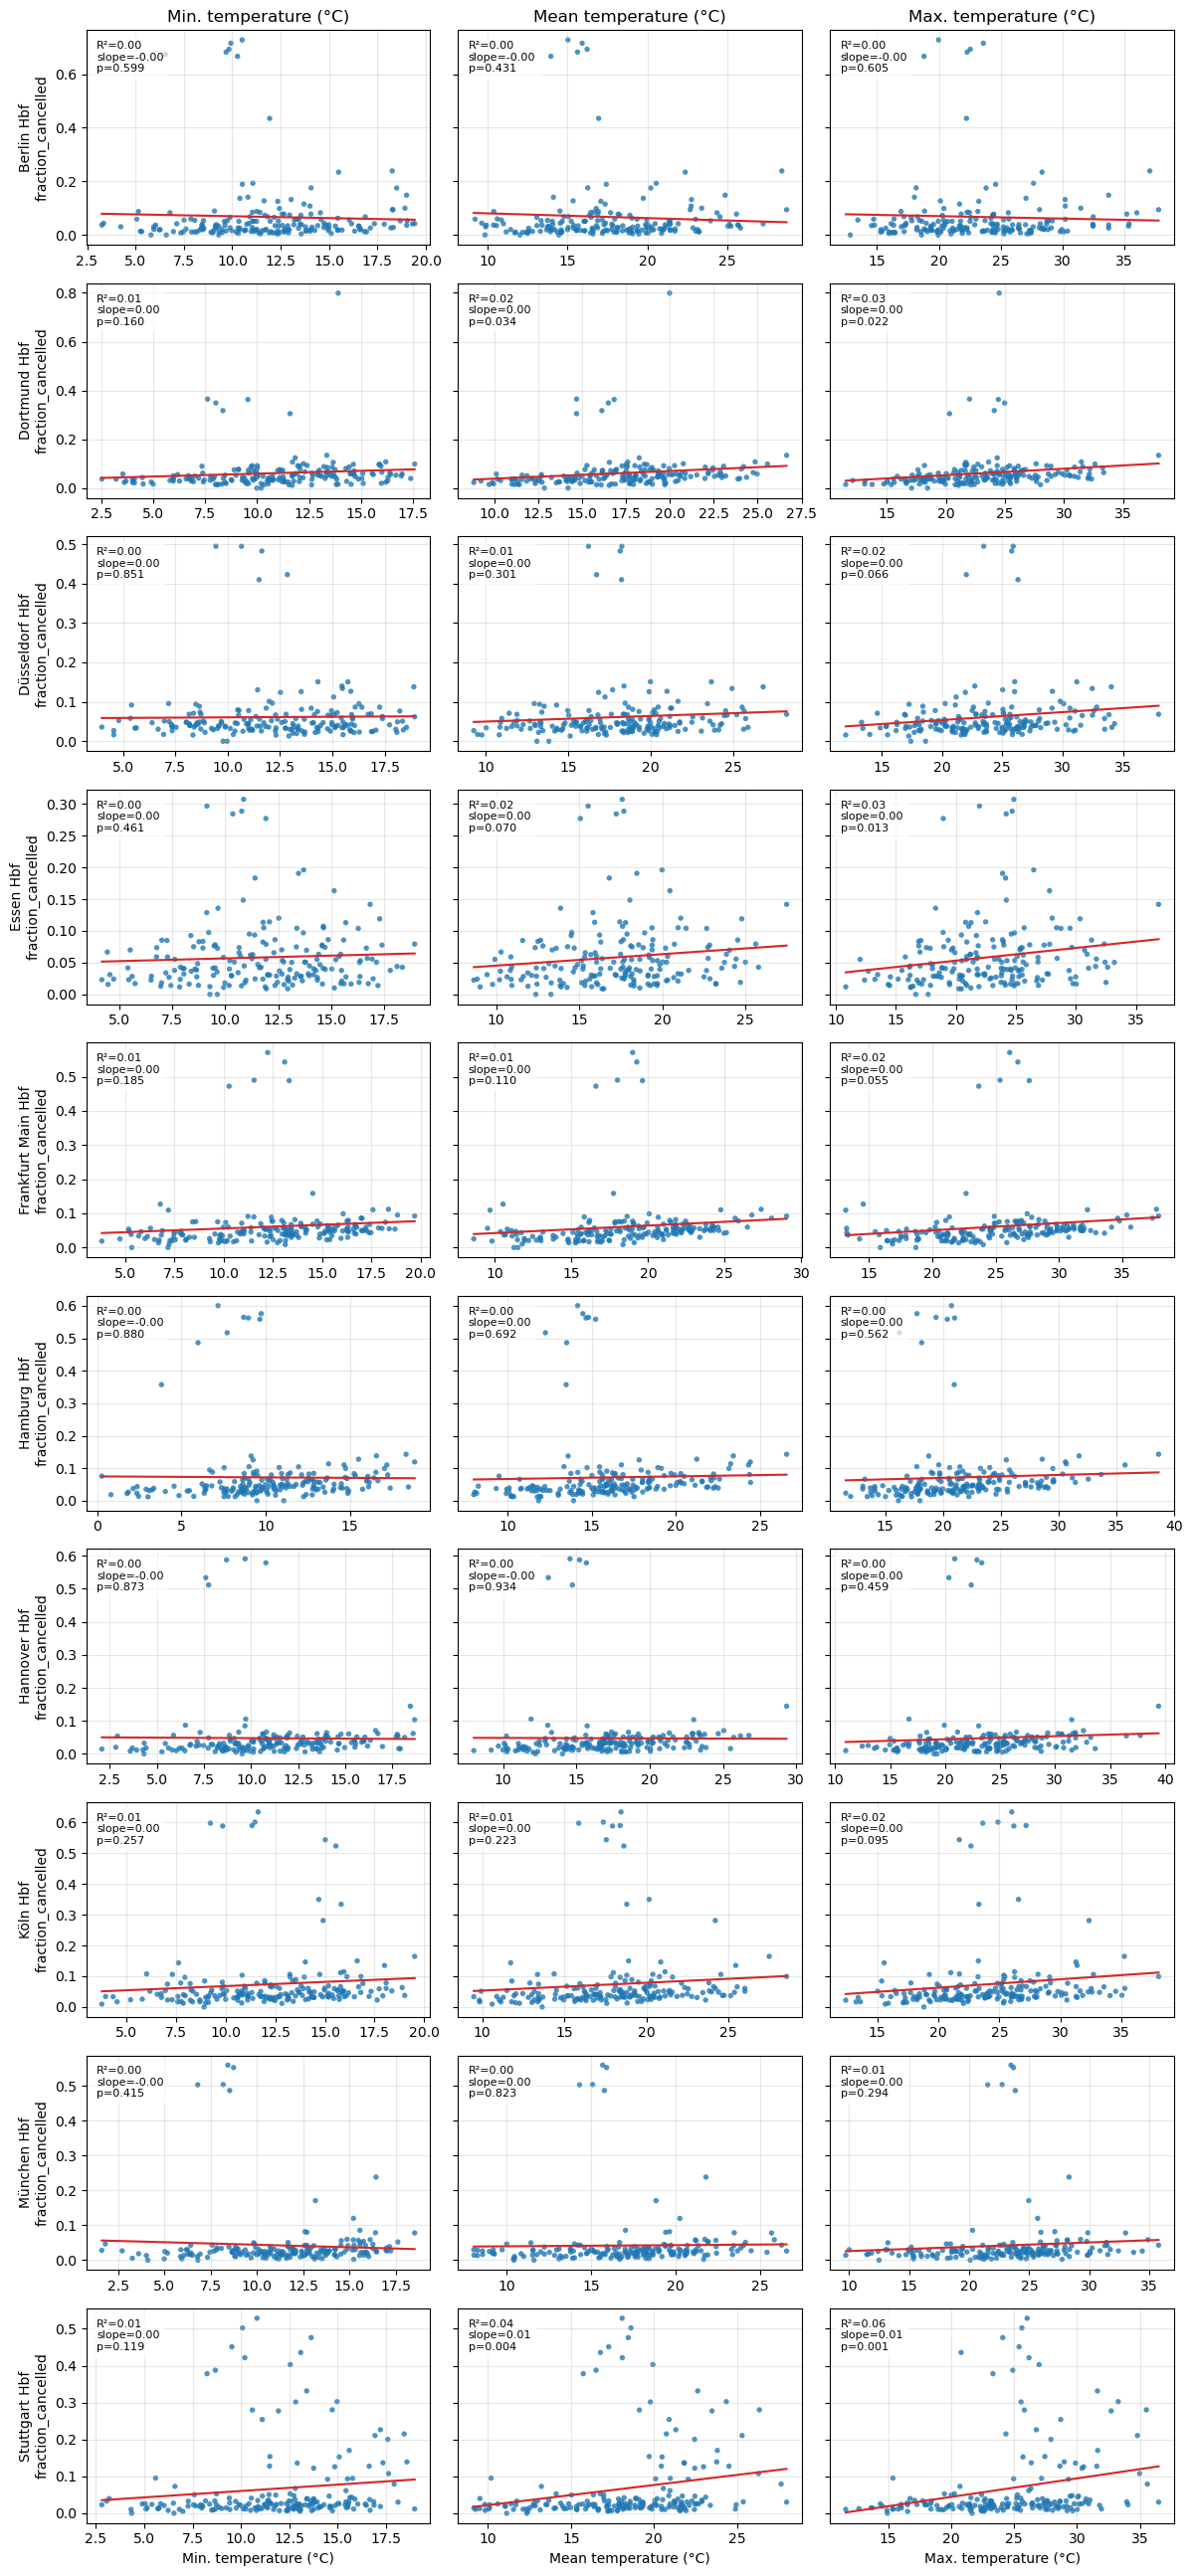

              city variable   n  slope  intercept      r    R2  p_value  stderr_slope
        Berlin Hbf       tn 185 -0.001      0.084 -0.039 0.002    0.599         0.003
        Berlin Hbf       tg 185 -0.002      0.098 -0.058 0.003    0.431         0.002
        Berlin Hbf       tx 185 -0.001      0.089 -0.038 0.001    0.605         0.002
      Dortmund Hbf       tn 185  0.002      0.036  0.104 0.011    0.160         0.002
      Dortmund Hbf       tg 185  0.003      0.007  0.156 0.024    0.034         0.001
      Dortmund Hbf       tx 185  0.003     -0.000  0.168 0.028    0.022         0.001
    Düsseldorf Hbf       tn 185  0.000      0.058  0.014 0.000    0.851         0.002
    Düsseldorf Hbf       tg 185  0.001      0.036  0.076 0.006    0.301         0.001
    Düsseldorf Hbf       tx 185  0.002      0.013  0.136 0.018    0.066         0.001
         Essen Hbf       tn 185  0.001      0.048  0.055 0.003    0.461         0.001
         Essen Hbf       tg 185  0.002      0.027  0.1

In [17]:
import glob
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# ---- settings ----
csv_dir = Path("/home/b/b383514/other/Train_Disrubtion/data/processed_new")
#out_file = csv_dir / "delay_vs_temperature.png"
DELAY_COL = "fraction_cancelled"          # or "fraction_delayed"
TEMP_COLS = ["tn", "tg", "tx"]
TEMP_LABELS = {"tn": "Min. temperature (°C)",
               "tg": "Mean temperature (°C)",
               "tx": "Max. temperature (°C)"}
# ------------------

files = sorted(csv_dir.glob("*.csv"))
n = len(files)
results = []

fig, axes = plt.subplots(n, 3, figsize=(12, 2.6 * n), sharey="row", squeeze=False)

for i, f in enumerate(files):
    d = pd.read_csv(f, parse_dates=["date"])
    city = f.stem.replace("_", " ")
    for j, var in enumerate(TEMP_COLS):
        ax = axes[i, j]
        ax.scatter(d[var], d[DELAY_COL], s=15, alpha=0.8, edgecolor="none")

        # --- linear regression (rows with both values present) ---
        sub = d[[var, DELAY_COL]].dropna()
        if len(sub) > 2:
            res = stats.linregress(sub[var], sub[DELAY_COL])
            xs = np.array([sub[var].min(), sub[var].max()])
            ax.plot(xs, res.intercept + res.slope * xs, color="C3", lw=1.5)
            ax.text(0.03, 0.95,
                    f"R²={res.rvalue**2:.2f}\nslope={res.slope:.2f}\np={res.pvalue:.3f}",
                    transform=ax.transAxes, va="top", fontsize=8,
                    bbox=dict(fc="white", ec="none", alpha=0.7))
            results.append({"city": city, "variable": var, "n": len(sub),
                            "slope": res.slope, "intercept": res.intercept,
                            "r": res.rvalue, "R2": res.rvalue**2,
                            "p_value": res.pvalue, "stderr_slope": res.stderr})

        ax.grid(alpha=0.3)
        if j == 0:
            ax.set_ylabel(f"{city}\n{DELAY_COL}")
        if i == 0:
            ax.set_title(TEMP_LABELS[var])
        if i == n - 1:
            ax.set_xlabel(TEMP_LABELS[var])

fig.tight_layout()
#fig.savefig(out_file, dpi=150)
plt.show()

summary = pd.DataFrame(results)
print(summary.round(3).to_string(index=False))
#summary.to_csv(csv_dir / "regression_summary.csv", index=False)

### Now combine all the data and look only for T > 25 °C

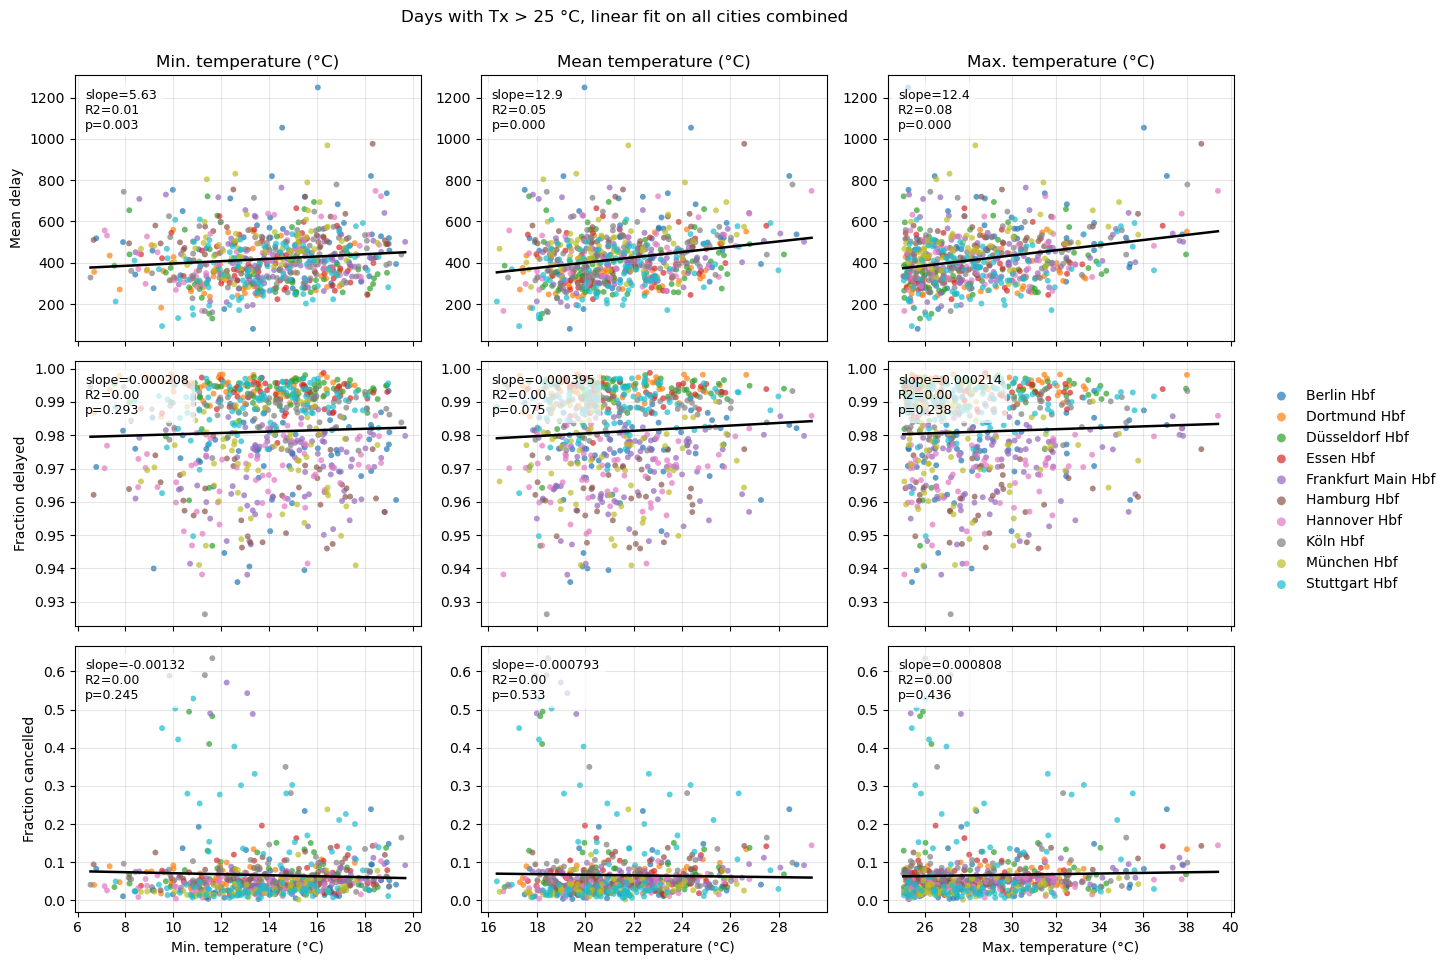

        y_variable x_variable   n   slope  intercept       r     R2  p_value  stderr_slope
        mean_delay         tn 695  5.6339   340.0717  0.1144 0.0131   0.0025        1.8592
        mean_delay         tg 695 12.8794   142.9536  0.2330 0.0543   0.0000        2.0424
        mean_delay         tx 695 12.4189    63.1177  0.2758 0.0761   0.0000        1.6442
  fraction_delayed         tn 695  0.0002     0.9782  0.0400 0.0016   0.2928        0.0002
  fraction_delayed         tg 695  0.0004     0.9726  0.0676 0.0046   0.0751        0.0002
  fraction_delayed         tx 695  0.0002     0.9750  0.0449 0.0020   0.2376        0.0002
fraction_cancelled         tn 695 -0.0013     0.0846 -0.0442 0.0020   0.2449        0.0011
fraction_cancelled         tg 695 -0.0008     0.0832 -0.0237 0.0006   0.5334        0.0013
fraction_cancelled         tx 695  0.0008     0.0431  0.0296 0.0009   0.4359        0.0010


In [18]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# ---- settings ----
csv_dir = Path("/home/b/b383514/other/Train_Disrubtion/data/processed_new")
TX_MIN = 25
ROWS = ["mean_delay", "fraction_delayed", "fraction_cancelled"]
ROW_LABELS = {"mean_delay": "Mean delay",
              "fraction_delayed": "Fraction delayed",
              "fraction_cancelled": "Fraction cancelled"}
TEMP_COLS = ["tn", "tg", "tx"]
TEMP_LABELS = {"tn": "Min. temperature (°C)",
               "tg": "Mean temperature (°C)",
               "tx": "Max. temperature (°C)"}
# ------------------

frames = []
for f in sorted(csv_dir.glob("*.csv")):
    d = pd.read_csv(f, parse_dates=["date"])
    d["city"] = f.stem.replace("_", " ")
    frames.append(d)
data = pd.concat(frames, ignore_index=True)
data = data[data["tx"] > TX_MIN]

cities = sorted(data["city"].unique())
cmap = plt.get_cmap("tab10")
colors = {c: cmap(i % 10) for i, c in enumerate(cities)}

results = []

fig, axes = plt.subplots(len(ROWS), len(TEMP_COLS),
                         figsize=(4.2 * len(TEMP_COLS), 3.2 * len(ROWS)),
                         sharex="col", squeeze=False)

for i, row in enumerate(ROWS):
    for j, var in enumerate(TEMP_COLS):
        ax = axes[i, j]
        for city in cities:
            s = data[data["city"] == city]
            ax.scatter(s[var], s[row], s=18, alpha=0.7, edgecolor="none",
                       color=colors[city], label=city)

        # one fit on all cities combined
        sub = data[[var, row]].dropna()
        res = stats.linregress(sub[var], sub[row])
        xs = np.array([sub[var].min(), sub[var].max()])
        ax.plot(xs, res.intercept + res.slope * xs, color="k", lw=1.8)
        ax.text(0.03, 0.95,
                f"slope={res.slope:.3g}\nR2={res.rvalue**2:.2f}\np={res.pvalue:.3f}",
                transform=ax.transAxes, va="top", fontsize=9,
                bbox=dict(fc="white", ec="none", alpha=0.7))

        results.append({"y_variable": row, "x_variable": var, "n": len(sub),
                        "slope": res.slope, "intercept": res.intercept,
                        "r": res.rvalue, "R2": res.rvalue**2,
                        "p_value": res.pvalue, "stderr_slope": res.stderr})

        ax.grid(alpha=0.3)
        if j == 0:
            ax.set_ylabel(ROW_LABELS[row])
        if i == 0:
            ax.set_title(TEMP_LABELS[var])
        if i == len(ROWS) - 1:
            ax.set_xlabel(TEMP_LABELS[var])

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1.0, 0.5),
           markerscale=1.5, frameon=False)
fig.suptitle(f"Days with Tx > {TX_MIN} °C, linear fit on all cities combined", y=1.0)
fig.tight_layout()
plt.show()

summary = pd.DataFrame(results)
print(summary.round(4).to_string(index=False))

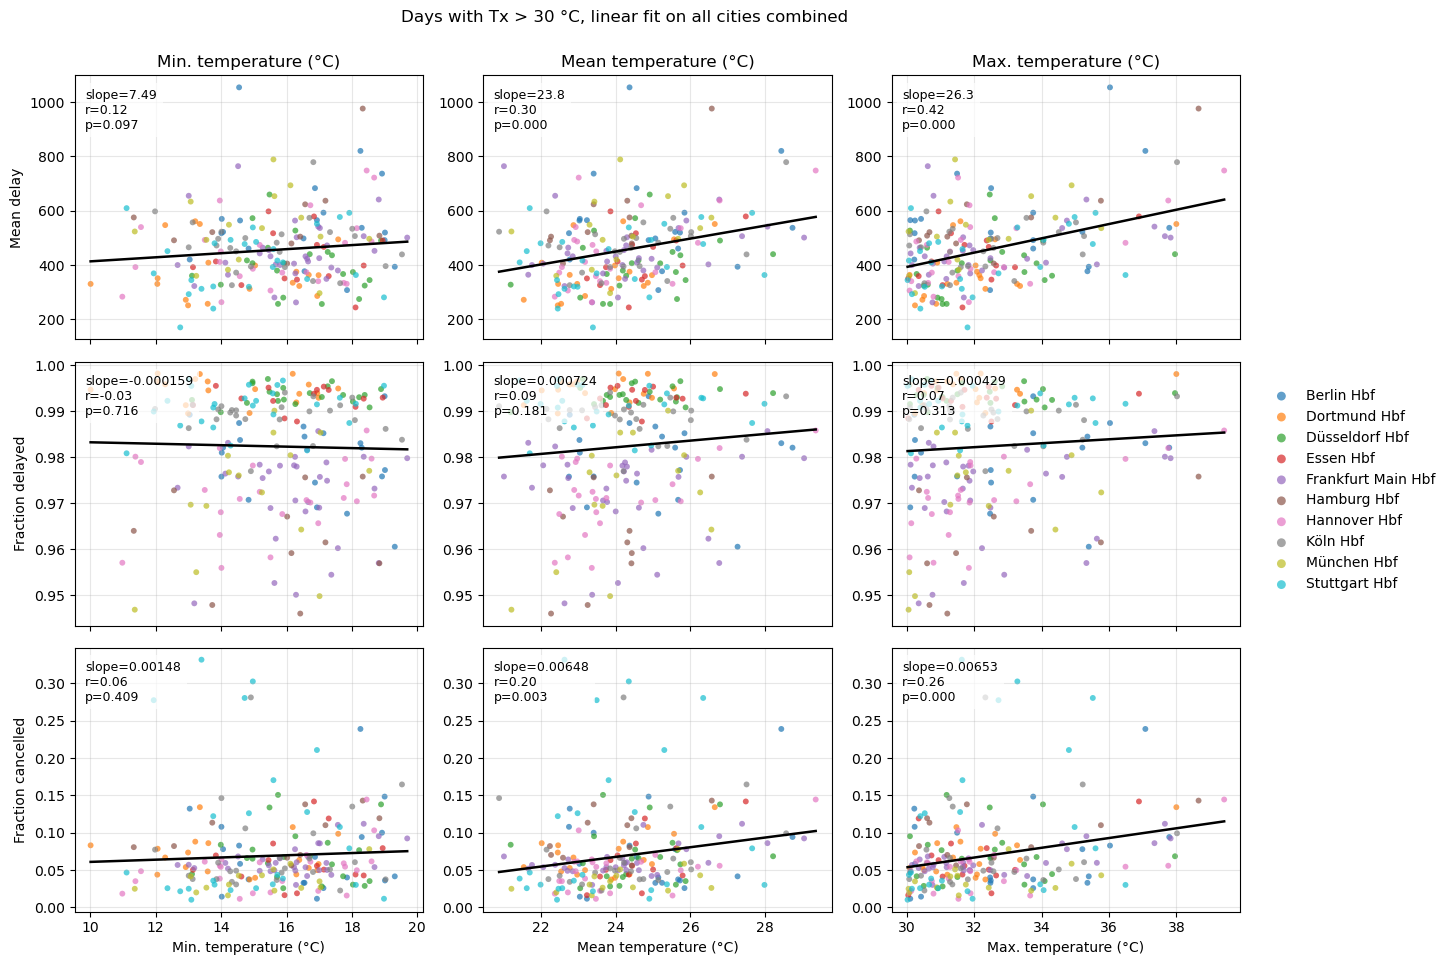

        y_variable x_variable   n   slope  intercept       r     R2  p_value  stderr_slope
        mean_delay         tn 204  7.4884   338.9087  0.1164 0.0135   0.0974        4.4970
        mean_delay         tg 204 23.8280  -121.8393  0.2978 0.0887   0.0000        5.3749
        mean_delay         tx 204 26.3228  -396.3782  0.4193 0.1758   0.0000        4.0103
  fraction_delayed         tn 204 -0.0002     0.9849 -0.0256 0.0007   0.7161        0.0004
  fraction_delayed         tg 204  0.0007     0.9648  0.0940 0.0088   0.1812        0.0005
  fraction_delayed         tx 204  0.0004     0.9685  0.0710 0.0050   0.3128        0.0004
fraction_cancelled         tn 204  0.0015     0.0461  0.0581 0.0034   0.4088        0.0018
fraction_cancelled         tg 204  0.0065    -0.0878  0.2045 0.0418   0.0033        0.0022
fraction_cancelled         tx 204  0.0065    -0.1421  0.2627 0.0690   0.0001        0.0017


In [19]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# ---- settings ----
csv_dir = Path("/home/b/b383514/other/Train_Disrubtion/data/processed_new")
TX_MIN = 30
ROWS = ["mean_delay", "fraction_delayed", "fraction_cancelled"]
ROW_LABELS = {"mean_delay": "Mean delay",
              "fraction_delayed": "Fraction delayed",
              "fraction_cancelled": "Fraction cancelled"}
TEMP_COLS = ["tn", "tg", "tx"]
TEMP_LABELS = {"tn": "Min. temperature (°C)",
               "tg": "Mean temperature (°C)",
               "tx": "Max. temperature (°C)"}
# ------------------

frames = []
for f in sorted(csv_dir.glob("*.csv")):
    d = pd.read_csv(f, parse_dates=["date"])
    d["city"] = f.stem.replace("_", " ")
    frames.append(d)
data = pd.concat(frames, ignore_index=True)
data = data[data["tx"] > TX_MIN]

cities = sorted(data["city"].unique())
cmap = plt.get_cmap("tab10")
colors = {c: cmap(i % 10) for i, c in enumerate(cities)}

results = []

fig, axes = plt.subplots(len(ROWS), len(TEMP_COLS),
                         figsize=(4.2 * len(TEMP_COLS), 3.2 * len(ROWS)),
                         sharex="col", squeeze=False)

for i, row in enumerate(ROWS):
    for j, var in enumerate(TEMP_COLS):
        ax = axes[i, j]
        for city in cities:
            s = data[data["city"] == city]
            ax.scatter(s[var], s[row], s=18, alpha=0.7, edgecolor="none",
                       color=colors[city], label=city)

        # one fit on all cities combined
        sub = data[[var, row]].dropna()
        res = stats.linregress(sub[var], sub[row])
        xs = np.array([sub[var].min(), sub[var].max()])
        ax.plot(xs, res.intercept + res.slope * xs, color="k", lw=1.8)
        ax.text(0.03, 0.95,
                f"slope={res.slope:.3g}\nr={res.rvalue:.2f}\np={res.pvalue:.3f}",
                transform=ax.transAxes, va="top", fontsize=9,
                bbox=dict(fc="white", ec="none", alpha=0.7))

        results.append({"y_variable": row, "x_variable": var, "n": len(sub),
                        "slope": res.slope, "intercept": res.intercept,
                        "r": res.rvalue, "R2": res.rvalue**2,
                        "p_value": res.pvalue, "stderr_slope": res.stderr})

        ax.grid(alpha=0.3)
        if j == 0:
            ax.set_ylabel(ROW_LABELS[row])
        if i == 0:
            ax.set_title(TEMP_LABELS[var])
        if i == len(ROWS) - 1:
            ax.set_xlabel(TEMP_LABELS[var])

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1.0, 0.5),
           markerscale=1.5, frameon=False)
fig.suptitle(f"Days with Tx > {TX_MIN} °C, linear fit on all cities combined", y=1.0)
fig.tight_layout()
plt.show()

summary = pd.DataFrame(results)
print(summary.round(4).to_string(index=False))

### Go towards boxplots

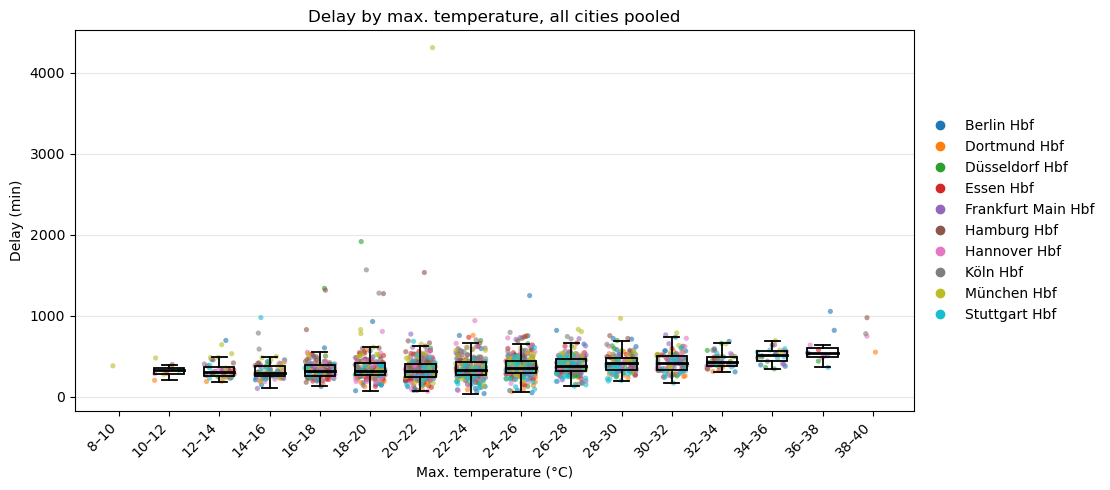

In [20]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ---- settings ----
csv_dir = Path("/home/b/b383514/other/Train_Disrubtion/data/processed_new")
DELAY_VAR = "mean_delay"  # delay in min
BIN_WIDTH = 2             # °C
MIN_N = 5                 # min. samples per box, otherwise no box (points still shown)
# ------------------

frames = []
for f in sorted(csv_dir.glob("*.csv")):
    d = pd.read_csv(f, parse_dates=["date"])
    d["city"] = f.stem.replace("_", " ")
    frames.append(d)
data = pd.concat(frames, ignore_index=True).dropna(subset=["tx", DELAY_VAR])

cities = sorted(data["city"].unique())
cmap = plt.get_cmap("tab10")
colors = {c: cmap(i % 10) for i, c in enumerate(cities)}

# temperature bins
lo = np.floor(data["tx"].min() / BIN_WIDTH) * BIN_WIDTH
hi = np.ceil(data["tx"].max() / BIN_WIDTH) * BIN_WIDTH
if hi == lo:
    hi = lo + BIN_WIDTH
edges = np.arange(lo, hi + BIN_WIDTH, BIN_WIDTH)
data["tbin"] = pd.cut(data["tx"], bins=edges, right=False)
bins = [b for b in data["tbin"].cat.categories if (data["tbin"] == b).any()]
bin_idx = {b: i for i, b in enumerate(bins)}

fig, ax = plt.subplots(figsize=(max(8, 0.7 * len(bins)), 5))
rng = np.random.default_rng(0)

# points colored by city (drawn first, so boxes sit on top)
for city in cities:
    s = data[data["city"] == city]
    x = s["tbin"].map(bin_idx).astype(float).values
    x = x + rng.uniform(-0.3, 0.3, size=len(x))
    ax.scatter(x, s[DELAY_VAR], s=14, alpha=0.6, edgecolor="none",
               color=colors[city], zorder=2)

# one pooled box per temperature bin
pos, vals = [], []
for b in bins:
    v = data.loc[data["tbin"] == b, DELAY_VAR].values
    if len(v) >= MIN_N:
        pos.append(bin_idx[b])
        vals.append(v)
ax.boxplot(vals, positions=pos, widths=0.6, showfliers=False, patch_artist=True,
           boxprops=dict(facecolor="none", edgecolor="k", lw=1.3),
           whiskerprops=dict(color="k", lw=1.3),
           capprops=dict(color="k", lw=1.3),
           medianprops=dict(color="k", lw=2), zorder=3)

ax.set_xticks(range(len(bins)))
ax.set_xticklabels([f"{b.left:g}–{b.right:g}" for b in bins], rotation=45, ha="right")
ax.set_xlabel("Max. temperature (°C)")
ax.set_ylabel("Delay (min)")
ax.set_title("Delay by max. temperature, all cities pooled")
ax.grid(axis="y", alpha=0.3)
ax.legend(handles=[Line2D([], [], marker="o", ls="", color=colors[c], label=c)
                   for c in cities],
          loc="center left", bbox_to_anchor=(1.0, 0.5), frameon=False)
fig.tight_layout()
plt.show()

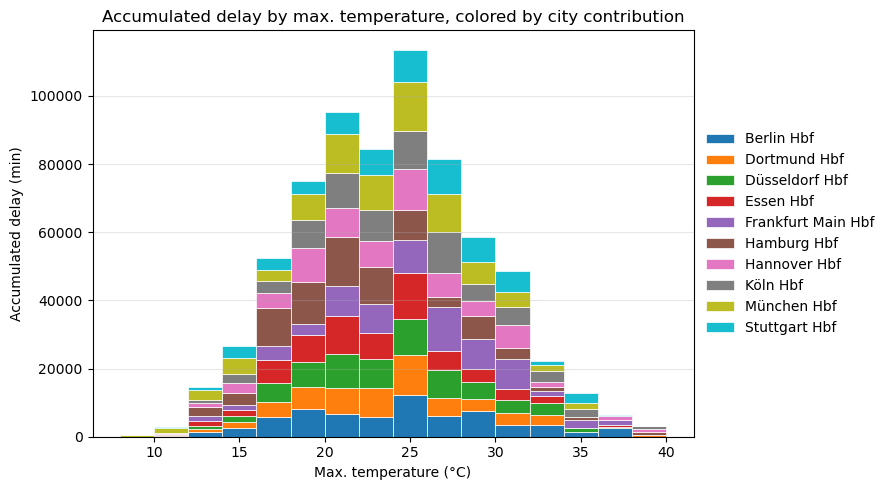

In [21]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- settings ----
csv_dir = Path("/home/b/b383514/other/Train_Disrubtion/data/processed_new")
DELAY_VAR = "mean_delay"  # <- column with the delay (min) that gets summed
BIN_WIDTH = 2             # °C
PER_DAY = False           # True: divide each bin's sum by number of days in that bin
# ------------------

frames = []
for f in sorted(csv_dir.glob("*.csv")):
    d = pd.read_csv(f, parse_dates=["date"])
    d["city"] = f.stem.replace("_", " ")
    frames.append(d)
data = pd.concat(frames, ignore_index=True).dropna(subset=["tx", DELAY_VAR])

cities = sorted(data["city"].unique())
cmap = plt.get_cmap("tab10")
colors = {c: cmap(i % 10) for i, c in enumerate(cities)}

# temperature bins
lo = np.floor(data["tx"].min() / BIN_WIDTH) * BIN_WIDTH
hi = np.ceil(data["tx"].max() / BIN_WIDTH) * BIN_WIDTH
if hi == lo:
    hi = lo + BIN_WIDTH
edges = np.arange(lo, hi + BIN_WIDTH, BIN_WIDTH)
data["tbin"] = pd.cut(data["tx"], bins=edges, right=False)

# summed delay per bin and city
sums = (data.groupby(["tbin", "city"], observed=False)[DELAY_VAR]
            .sum().unstack("city").reindex(columns=cities).fillna(0))
if PER_DAY:
    n_days = data.groupby("tbin", observed=False).size().replace(0, np.nan)
    sums = sums.div(n_days, axis=0).fillna(0)

# stacked histogram
fig, ax = plt.subplots(figsize=(9, 5))
bottom = np.zeros(len(sums))
for city in cities:
    ax.bar(edges[:-1], sums[city].values, width=BIN_WIDTH, align="edge",
           bottom=bottom, color=colors[city], edgecolor="white", lw=0.5,
           label=city)
    bottom += sums[city].values

ax.set_xlabel("Max. temperature (°C)")
ax.set_ylabel("Summed delay per day (min)" if PER_DAY else "Accumulated delay (min)")
ax.set_title("Accumulated delay by max. temperature, colored by city contribution")
ax.grid(axis="y", alpha=0.3)
ax.legend(loc="center left", bbox_to_anchor=(1.0, 0.5), frameon=False)
fig.tight_layout()
plt.show()

Number of entries per Tx bin and city:
city   Berlin Hbf  Dortmund Hbf  Düsseldorf Hbf  Essen Hbf  Frankfurt Main Hbf  Hamburg Hbf  Hannover Hbf  Köln Hbf  München Hbf  Stuttgart Hbf  total
8–10            0             0               0          0                   0            0             0         0            1              0      1
10–12           0             1               0          1                   0            1             1         0            4              1      9
12–14           3             4               3          5                   4            8             4         4            6              3     44
14–16           9             7               6          6                   5           10            10         6           13              9     81
16–18          16            16              15         22                  13           28            12        11            8             11    152
18–20          27            23              18        

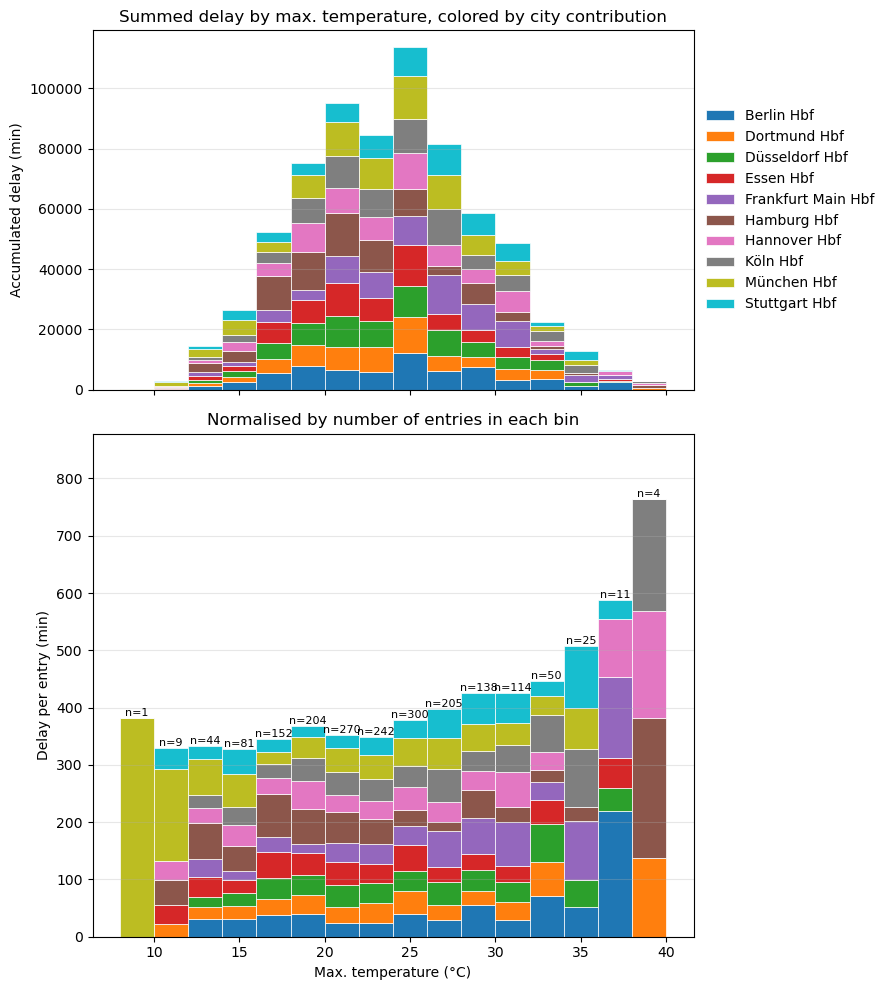

In [22]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- settings ----
csv_dir = Path("/home/b/b383514/other/Train_Disrubtion/data/processed_new")
DELAY_VAR = "mean_delay"  # <- column with the delay (min) that gets summed
BIN_WIDTH = 2             # °C
# ------------------

frames = []
for f in sorted(csv_dir.glob("*.csv")):
    d = pd.read_csv(f, parse_dates=["date"])
    d["city"] = f.stem.replace("_", " ")
    frames.append(d)
data = pd.concat(frames, ignore_index=True).dropna(subset=["tx", DELAY_VAR])

cities = sorted(data["city"].unique())
cmap = plt.get_cmap("tab10")
colors = {c: cmap(i % 10) for i, c in enumerate(cities)}

# temperature bins
lo = np.floor(data["tx"].min() / BIN_WIDTH) * BIN_WIDTH
hi = np.ceil(data["tx"].max() / BIN_WIDTH) * BIN_WIDTH
if hi == lo:
    hi = lo + BIN_WIDTH
edges = np.arange(lo, hi + BIN_WIDTH, BIN_WIDTH)
data["tbin"] = pd.cut(data["tx"], bins=edges, right=False)

# summed delay and number of entries per bin and city
grp = data.groupby(["tbin", "city"], observed=False)[DELAY_VAR]
sums = grp.sum().unstack("city").reindex(columns=cities).fillna(0)
counts = grp.size().unstack("city").reindex(columns=cities).fillna(0).astype(int)
n_total = counts.sum(axis=1)

# normalised: each city's sum divided by ALL entries in the bin
# -> segments add up to the mean delay per entry in that bin
norm = sums.div(n_total.replace(0, np.nan), axis=0).fillna(0)

# ---- print number of entries ----
table = counts.copy()
table["total"] = n_total
table.index = [f"{b.left:g}–{b.right:g}" for b in table.index]
print("Number of entries per Tx bin and city:")
print(table.to_string())
print(f"\nTotal entries: {n_total.sum()}")

# ---- plots ----
def stacked(ax, values):
    bottom = np.zeros(len(values))
    for city in cities:
        ax.bar(edges[:-1], values[city].values, width=BIN_WIDTH, align="edge",
               bottom=bottom, color=colors[city], edgecolor="white", lw=0.5,
               label=city)
        bottom += values[city].values
    return bottom

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 10), sharex=True,
                               gridspec_kw={"height_ratios": [1, 1.4]})

stacked(ax1, sums)
ax1.set_ylabel("Accumulated delay (min)")
ax1.set_title("Summed delay by max. temperature, colored by city contribution")

tops = stacked(ax2, norm)
for x, top, n in zip(edges[:-1], tops, n_total.values):
    ax2.text(x + BIN_WIDTH / 2, top, f"n={n}", ha="center", va="bottom", fontsize=8)
ax2.set_ylim(0, tops.max() * 1.15)   # headroom above the tallest bar
ax2.set_ylabel("Delay per entry (min)")
ax2.set_xlabel("Max. temperature (°C)")
ax2.set_title("Normalised by number of entries in each bin")

for ax in (ax1, ax2):
    ax.grid(axis="y", alpha=0.3)
ax1.legend(loc="center left", bbox_to_anchor=(1.0, 0.5), frameon=False)
fig.tight_layout()
plt.show()

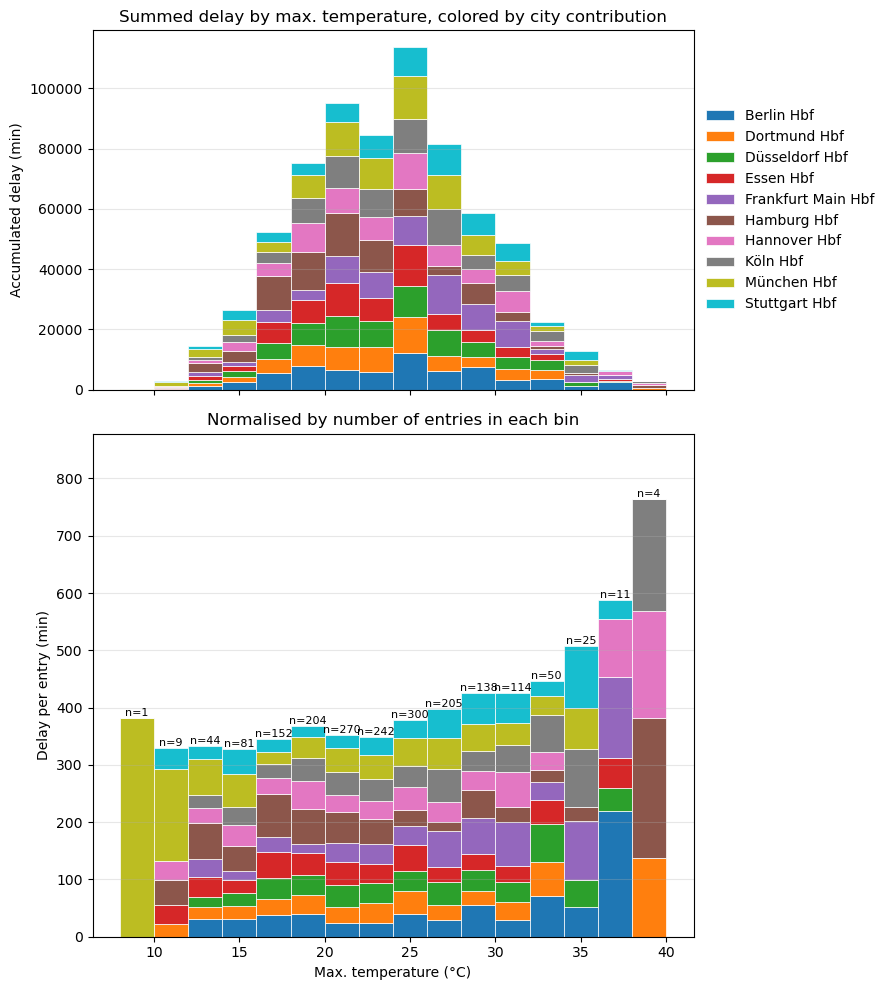

In [23]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 10), sharex=True,
                               gridspec_kw={"height_ratios": [1, 1.4]})

stacked(ax1, sums)
ax1.set_ylabel("Accumulated delay (min)")
ax1.set_title("Summed delay by max. temperature, colored by city contribution")

tops = stacked(ax2, norm)
for x, top, n in zip(edges[:-1], tops, n_total.values):
    ax2.text(x + BIN_WIDTH / 2, top, f"n={n}", ha="center", va="bottom", fontsize=8)
ax2.set_ylim(0, tops.max() * 1.15)   # headroom above the tallest bar
ax2.set_ylabel("Delay per entry (min)")
ax2.set_xlabel("Max. temperature (°C)")
ax2.set_title("Normalised by number of entries in each bin")

for ax in (ax1, ax2):
    ax.grid(axis="y", alpha=0.3)
ax1.legend(loc="center left", bbox_to_anchor=(1.0, 0.5), frameon=False)
fig.tight_layout()
plt.show()

Number of entries per city and bin:
tbin                Tx < 30 °C  Tx ≥ 30 °C
city                                      
Berlin Hbf                 166          19
Dortmund Hbf               166          19
Düsseldorf Hbf             163          22
Essen Hbf                  171          14
Frankfurt Main Hbf         153          32
Hamburg Hbf                175          10
Hannover Hbf               162          23
Köln Hbf                   160          25
München Hbf                170          15
Stuttgart Hbf              160          25

Total entries: 1850


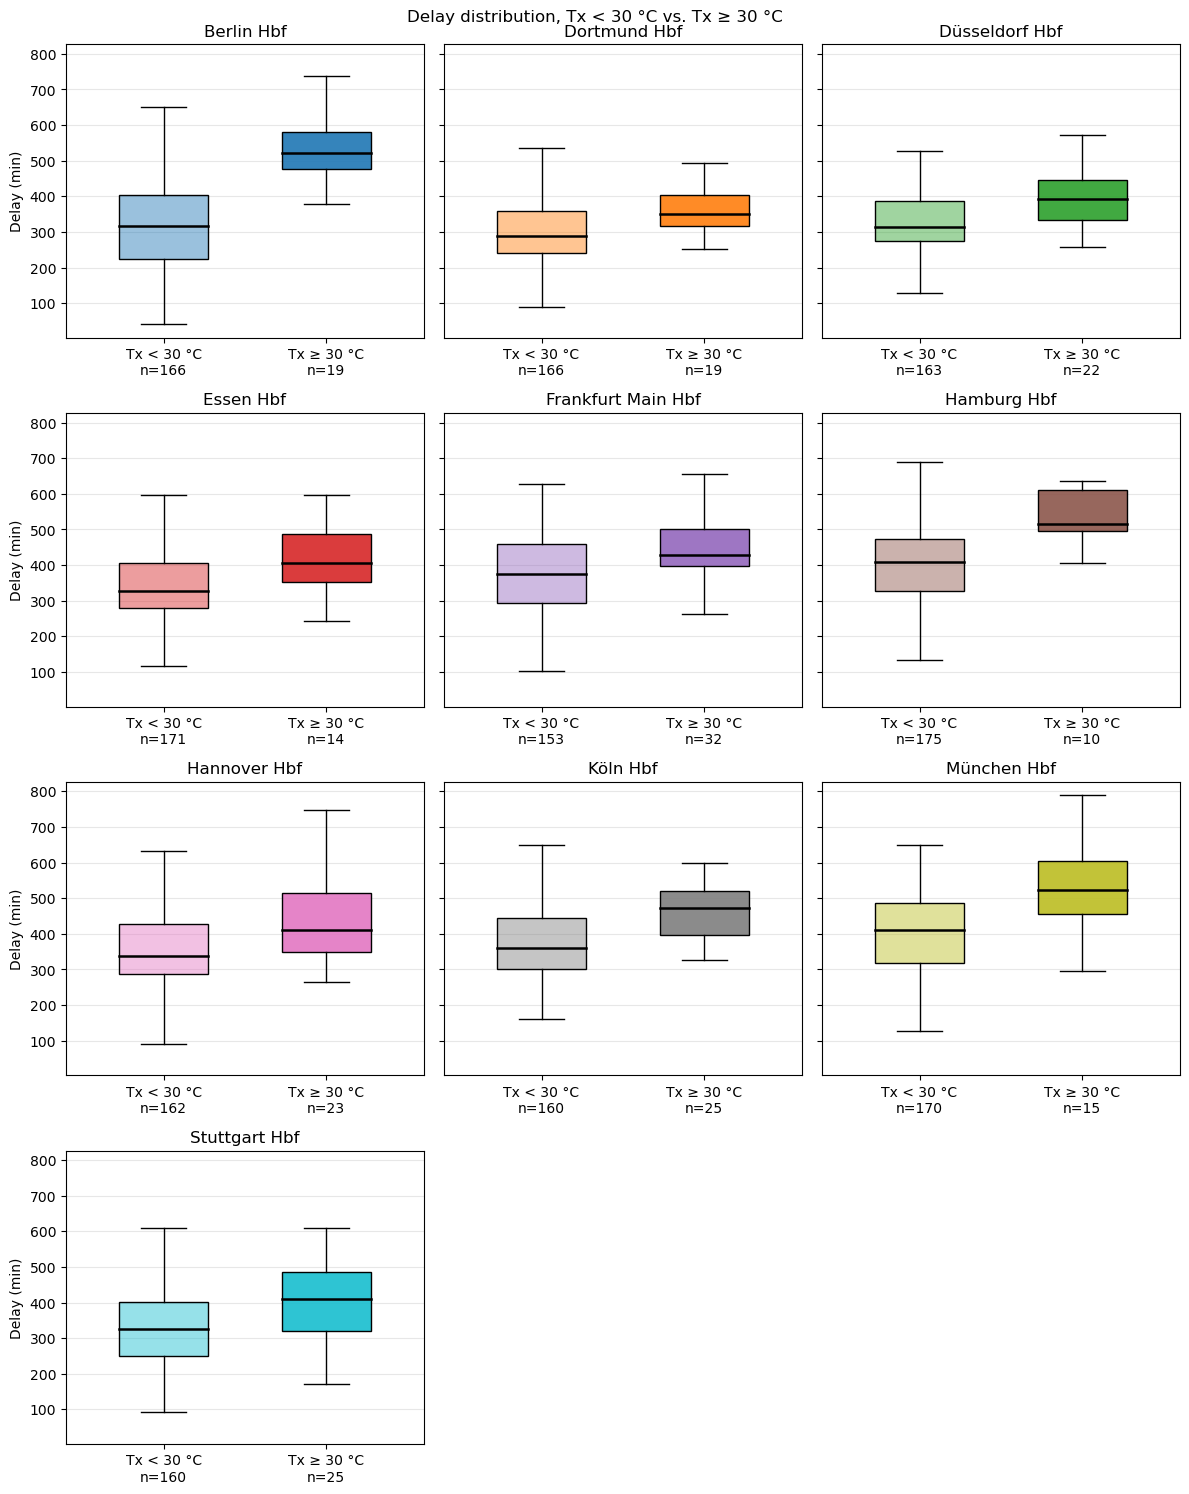

In [24]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba

# ---- settings ----
csv_dir = Path("/home/b/b383514/other/Train_Disrubtion/data/processed_new")
DELAY_VAR = "mean_delay"  # <- column with the delay (min)
THRESHOLD = 30            # °C; below -> "cold" box, at or above -> "hot" box
NCOLS = 3                 # panels per row
SHOW_FLIERS = True        # show outliers
# ------------------

frames = []
for f in sorted(csv_dir.glob("*.csv")):
    d = pd.read_csv(f, parse_dates=["date"])
    d["city"] = f.stem.replace("_", " ")
    frames.append(d)
data = pd.concat(frames, ignore_index=True).dropna(subset=["tx", DELAY_VAR])

cities = sorted(data["city"].unique())
cmap = plt.get_cmap("tab10")
colors = {c: cmap(i % 10) for i, c in enumerate(cities)}

labels = [f"Tx < {THRESHOLD} °C", f"Tx ≥ {THRESHOLD} °C"]
data["tbin"] = np.where(data["tx"] < THRESHOLD, labels[0], labels[1])

# ---- print number of entries ----
counts = (data.groupby(["city", "tbin"]).size()
              .unstack("tbin").reindex(index=cities, columns=labels)
              .fillna(0).astype(int))
print("Number of entries per city and bin:")
print(counts.to_string())
print(f"\nTotal entries: {counts.values.sum()}")

# ---- plot ----
nrows = int(np.ceil(len(cities) / NCOLS))
fig, axes = plt.subplots(nrows, NCOLS, figsize=(4 * NCOLS, 3.8 * nrows),
                         squeeze=False, sharey=True)

for ax, city in zip(axes.ravel(), cities):
    s = data[data["city"] == city]
    pos, vals, alphas = [], [], []
    for k, lab in enumerate(labels):
        v = s.loc[s["tbin"] == lab, DELAY_VAR].values
        if len(v) > 0:
            pos.append(k)
            vals.append(v)
            alphas.append(0.45 if k == 0 else 0.9)   # cold lighter, hot full color
    if vals:
        bp = ax.boxplot(vals, positions=pos, widths=0.55, patch_artist=True,
                        showfliers=False,
                        medianprops=dict(color="k", lw=1.8),
                        flierprops=dict(marker="o", markersize=3,
                                        markerfacecolor="grey",
                                        markeredgecolor="none", alpha=0.6))
        for patch, a in zip(bp["boxes"], alphas):
            patch.set_facecolor(to_rgba(colors[city], a))
            patch.set_edgecolor("k")
    ax.set_xticks([0, 1])
    ax.set_xticklabels([f"{lab}\nn={counts.loc[city, lab]}" for lab in labels])
    ax.set_xlim(-0.6, 1.6)
    ax.set_title(city)
    ax.grid(axis="y", alpha=0.3)

for ax in axes.ravel()[len(cities):]:
    ax.set_visible(False)
for ax in axes[:, 0]:
    ax.set_ylabel("Delay (min)")
fig.suptitle(f"Delay distribution, Tx < {THRESHOLD} °C vs. Tx ≥ {THRESHOLD} °C")
fig.tight_layout()
plt.show()

Number of entries per city and bin:
tbin                Tx < 30 °C  Tx ≥ 30 °C
city                                      
Berlin Hbf                 166          19
Dortmund Hbf               166          19
Düsseldorf Hbf             163          22
Essen Hbf                  171          14
Frankfurt Main Hbf         153          32
Hamburg Hbf                175          10
Hannover Hbf               162          23
Köln Hbf                   160          25
München Hbf                170          15
Stuttgart Hbf              160          25

Total entries: 1850


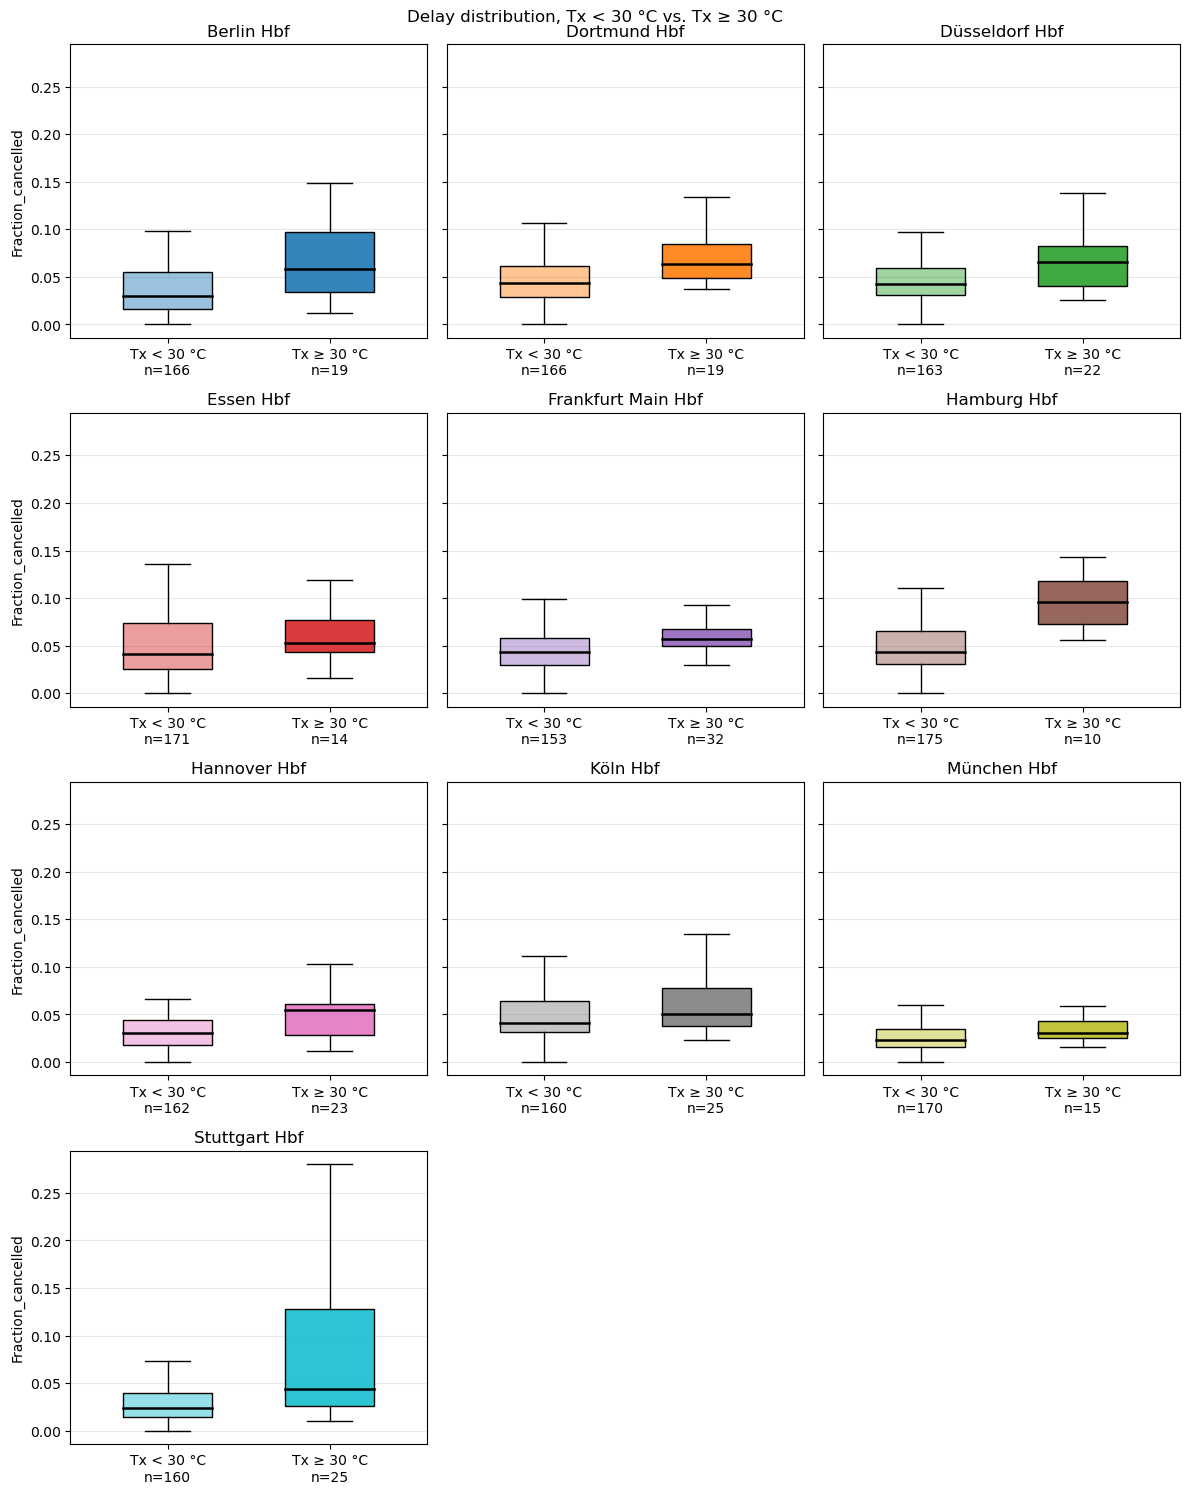

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba

# ---- settings ----
csv_dir = Path("/home/b/b383514/other/Train_Disrubtion/data/processed_new")
DELAY_VAR = "fraction_cancelled"  # <- column with the delay (min)
THRESHOLD = 30            # °C; below -> "cold" box, at or above -> "hot" box
NCOLS = 3                 # panels per row
SHOW_FLIERS = True        # show outliers
# ------------------

frames = []
for f in sorted(csv_dir.glob("*.csv")):
    d = pd.read_csv(f, parse_dates=["date"])
    d["city"] = f.stem.replace("_", " ")
    frames.append(d)
data = pd.concat(frames, ignore_index=True).dropna(subset=["tx", DELAY_VAR])

cities = sorted(data["city"].unique())
cmap = plt.get_cmap("tab10")
colors = {c: cmap(i % 10) for i, c in enumerate(cities)}

labels = [f"Tx < {THRESHOLD} °C", f"Tx ≥ {THRESHOLD} °C"]
data["tbin"] = np.where(data["tx"] < THRESHOLD, labels[0], labels[1])

# ---- print number of entries ----
counts = (data.groupby(["city", "tbin"]).size()
              .unstack("tbin").reindex(index=cities, columns=labels)
              .fillna(0).astype(int))
print("Number of entries per city and bin:")
print(counts.to_string())
print(f"\nTotal entries: {counts.values.sum()}")

# ---- plot ----
nrows = int(np.ceil(len(cities) / NCOLS))
fig, axes = plt.subplots(nrows, NCOLS, figsize=(4 * NCOLS, 3.8 * nrows),
                         squeeze=False, sharey=True)

for ax, city in zip(axes.ravel(), cities):
    s = data[data["city"] == city]
    pos, vals, alphas = [], [], []
    for k, lab in enumerate(labels):
        v = s.loc[s["tbin"] == lab, DELAY_VAR].values
        if len(v) > 0:
            pos.append(k)
            vals.append(v)
            alphas.append(0.45 if k == 0 else 0.9)   # cold lighter, hot full color
    if vals:
        bp = ax.boxplot(vals, positions=pos, widths=0.55, patch_artist=True,
                        showfliers=False,
                        medianprops=dict(color="k", lw=1.8),
                        flierprops=dict(marker="o", markersize=3,
                                        markerfacecolor="grey",
                                        markeredgecolor="none", alpha=0.6))
        for patch, a in zip(bp["boxes"], alphas):
            patch.set_facecolor(to_rgba(colors[city], a))
            patch.set_edgecolor("k")
    ax.set_xticks([0, 1])
    ax.set_xticklabels([f"{lab}\nn={counts.loc[city, lab]}" for lab in labels])
    ax.set_xlim(-0.6, 1.6)
    ax.set_title(city)
    ax.grid(axis="y", alpha=0.3)

for ax in axes.ravel()[len(cities):]:
    ax.set_visible(False)
for ax in axes[:, 0]:
    ax.set_ylabel("Fraction_cancelled")
fig.suptitle(f"Delay distribution, Tx < {THRESHOLD} °C vs. Tx ≥ {THRESHOLD} °C")
fig.tight_layout()
plt.show()